This workbook is to try the clustering algorithm after we add in the country groupings based on study by Cashion 2016 and all the fishing entity that are present in the SAU database.


In [1]:
# Load libraries
import pandas as pd
from feature_engineering import transform_data
from dimension_reduction import dimension_reduction
from top_categories_per_type import plot_top_categories
from gdp_lat_cleaning import gdp_lat_cleaning
from hierarchical_clustering import plot_heatmap, plot_dendrogram

raw_path = "../data/raw/adr6921_Suppl_Excel_v2.csv"
gdp_path = "../data/raw/compiled_gdp.csv"
mean_lat_path = "../data/raw/geo_mean_location.csv"
output_path = '../data/processed/'
graph_output_path = '../results/'

In [2]:
# Read in raw data
df = pd.read_csv(raw_path, encoding_errors='replace')
gdp_per_capita = pd.read_csv(gdp_path)
mean_latitude = pd.read_csv(mean_lat_path)

# Transform data and obain final dataframe with counts of factories by country and attribute category
df = transform_data(df, False)

# Set 'country' as index
X = df.set_index('country')
# obtain features for clustering
X = X.drop(columns=['total_factories'])

In [3]:
n_components = 5

# Perform dimensionality reduction using NMF
W, H = dimension_reduction(X, n_components=n_components)

# Obtain list of countries in W
countries = W.index.tolist()

# Create with top categories contributing to each type
top_categories = plot_top_categories(H, 30, False)

top_categories

alt.FacetChart(...)

In [4]:
W.head()

,Type 1,Type 2,Type 3,Type 4,Type 5
country,,,,,
Argentina,0.0,0.099640,0.000000,0.692970,0.207390
Australia,0.0,0.000000,0.840692,0.000000,0.159308
Brazil,0.0,0.000000,1.000000,0.000000,0.000000
Canada,0.0,0.168408,0.204320,0.351054,0.276218
Chile,0.0,0.000348,0.758112,0.006893,0.234647


In [5]:
gdp_per_capita.head()

,country_name,GDP_per_capita,source,link
0,Albania,6069.439031,worldbank-2019,NaN
1,Algeria,4468.453419,worldbank-2019,NaN
2,American Samoa,12886.135950,worldbank-2019,NaN
3,Angola,2493.678844,worldbank-2019,NaN
4,Antigua & Barbuda,18896.372180,worldbank-2019,NaN


In [6]:
clean_gdp = gdp_per_capita.set_index("country_name")[['GDP_per_capita']]

In [7]:
clean_gdp.head()

,GDP_per_capita
country_name,
Albania,6069.439031
Algeria,4468.453419
American Samoa,12886.135950
Angola,2493.678844
Antigua & Barbuda,18896.372180


In [8]:
mean_latitude.head()

,geo_entity_id,geo_name,lon,lat
0,1.0,Alaska (USA),0.000000,61.295554
1,2.0,Albania,19.171094,40.760915
2,3.0,Algeria,3.216740,36.933958
3,4.0,American Samoa (USA),-169.473750,-13.790833
4,5.0,Andaman & Nicobar Isl. (India),92.252348,9.789049


In [9]:
clean_latitude = mean_latitude.set_index("geo_name")[["lat"]] 

In [10]:
clean_latitude

,lat
geo_name,
Alaska (USA),61.295554
Albania,40.760915
Algeria,36.933958
American Samoa (USA),-13.790833
Andaman & Nicobar Isl. (India),9.789049
...,...
Virgin Isl. (UK),20.023051
Wake Isl. (USA),19.344531
Wallis & Futuna Isl. (France),-12.892204


In [11]:
cashion_data = pd.read_csv('../data/raw/sau_fishing_entity_info.csv')

In [12]:
cashion_data.head()

,fishing_entity_id,name,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type
0,200,Alaska (USA),Others,Unknown,n,n,n,n,n,Unknown
1,1,Albania,Developed,only_bait,n,y,n,n,n,B
2,2,Algeria,Others,only_bait,n,n,n,y,n,C
3,3,American Samoa,Others,only_dhc,n,n,n,n,n,C
4,4,Angola,Least Developed,dedicated_industry,y,y,y,y,n,A


In [13]:
cd = cashion_data.set_index('name')

In [14]:
country_list = pd.read_csv('../data/raw/country_translations.csv')

In [15]:
# Obtain list of countries in SAU that need should be considered
countries = country_list[country_list['is_currently_used_for_reconstruction'] == True]['sau_name']
all_country = pd.DataFrame(index=countries)

In [16]:
# Load in latitude data
mean_lat_path = "../data/raw/geo_mean_location.csv"
mean_latitude = pd.read_csv(mean_lat_path)
clean_latitude = mean_latitude.set_index("geo_name")[["lat"]] 
clean_latitude.head()

,lat
geo_name,
Alaska (USA),61.295554
Albania,40.760915
Algeria,36.933958
American Samoa (USA),-13.790833
Andaman & Nicobar Isl. (India),9.789049


In [17]:
sau_lat_name = country_list[country_list['is_currently_used_for_reconstruction'] == True][['sau_name', 'mean_lat_geo_name']]

In [18]:
# rename index of clean_latitude to match sau_lat_name
cleaned_latitude = clean_latitude.join(sau_lat_name.set_index('mean_lat_geo_name'), how='inner').set_index('sau_name')

In [19]:
# add gdp and latitude to all countries
combined = all_country.join(clean_gdp, how='left').join(cleaned_latitude, how='left')

In [20]:
combined

,GDP_per_capita,lat
sau_name,,
Albania,6069.439031,40.760915
Algeria,4468.453419,36.933958
American Samoa,12886.135950,-13.790833
Angola,2493.678844,-11.139923
Anguilla (UK),25614.509760,19.939333
...,...,...
Vanuatu,3207.446505,-19.009306
Venezuela,2523.112752,12.552886
Viet Nam,3440.900254,13.493825


In [21]:
from sklearn.preprocessing import MinMaxScaler
# Scale GDP and latitude data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(combined)

In [22]:
combined[['GDP_per_capita', 'lat']] = scaled_data

In [23]:
combined.head()

,GDP_per_capita,lat
sau_name,,
Albania,0.052414,0.749789
Algeria,0.038588,0.718843
American Samoa,0.111281,0.308669
Angola,0.021535,0.330105
Anguilla (UK),0.221200,0.581420


In [24]:
sau_factory_name = country_list[country_list['is_currently_used_for_reconstruction'] == True][['sau_name', 'factory_country']]

In [25]:
translated_W = W.join(sau_factory_name.set_index('factory_country'), how='inner').set_index('sau_name')

In [26]:
W[~W.index.isin(translated_W.index.to_list())]

,Type 1,Type 2,Type 3,Type 4,Type 5
country,,,,,
Faroe Islands,0.000000,0.000000,0.000000,0.000000,1.000000
South Korea,0.000000,0.108767,0.000000,0.664769,0.226464
Kazakhstan,NaN,NaN,NaN,NaN,NaN
Russia,NaN,NaN,NaN,NaN,NaN
United States of America,0.370725,0.037703,0.053952,0.450108,0.087511
Vietnam,0.064751,0.476772,0.079714,0.015345,0.363417


In [27]:
combined = combined.join(translated_W, how='left').fillna(0)

In [28]:
combined.head()

,GDP_per_capita,lat,Type 1,Type 2,Type 3,Type 4,Type 5
sau_name,,,,,,,
Albania,0.052414,0.749789,0.0,0.0,0.0,0.0,0.0
Algeria,0.038588,0.718843,0.0,0.0,0.0,0.0,0.0
American Samoa,0.111281,0.308669,0.0,0.0,0.0,0.0,0.0
Angola,0.021535,0.330105,0.0,0.0,0.0,0.0,0.0
Anguilla (UK),0.221200,0.581420,0.0,0.0,0.0,0.0,0.0


In [29]:
cd = cd.drop(columns=['fishing_entity_id'])
cd.head()

,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type
name,,,,,,,,
Alaska (USA),Others,Unknown,n,n,n,n,n,Unknown
Albania,Developed,only_bait,n,y,n,n,n,B
Algeria,Others,only_bait,n,n,n,y,n,C
American Samoa,Others,only_dhc,n,n,n,n,n,C
Angola,Least Developed,dedicated_industry,y,y,y,y,n,A


In [30]:
final = combined.join(cd, how='left')

In [31]:
final[final.index == 'Viet Nam']

,GDP_per_capita,lat,Type 1,Type 2,Type 3,Type 4,Type 5,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type
sau_name,,,,,,,,,,,,,,,
Viet Nam,0.029715,0.5293,0.064751,0.476772,0.079714,0.015345,0.363417,Developing,dedicated_industry,n,n,y,y,y,A


In [32]:
import numpy as np
# Obtain factory count dataframe to add to dataframe
factory_count = df[['country', 'total_factories']].set_index('country')

# log transform factory count to reduce skewness
logged_factory_count = np.log(factory_count)

# scale 

logged_factory_count

factory_scaler = MinMaxScaler()
scaled_factory_count = factory_scaler.fit_transform(logged_factory_count)
factory_count_logged_scaled = pd.DataFrame(scaled_factory_count, index=logged_factory_count.index, columns=['scaled_factory_count'])

In [33]:
translated_factory_count = factory_count_logged_scaled.join(sau_factory_name.set_index('factory_country'), how='inner').set_index('sau_name')

In [34]:
final = final.join(translated_factory_count, how='left')

In [35]:
final['scaled_factory_count'] = final['scaled_factory_count'].fillna(0)

In [36]:
final['cashion_type'] = final['cashion_type'].fillna('unknown')

In [37]:
final.head()

,GDP_per_capita,lat,Type 1,Type 2,Type 3,Type 4,Type 5,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type,scaled_factory_count
sau_name,,,,,,,,,,,,,,,,
Albania,0.052414,0.749789,0.0,0.0,0.0,0.0,0.0,Developed,only_bait,n,y,n,n,n,B,0.0
Algeria,0.038588,0.718843,0.0,0.0,0.0,0.0,0.0,Others,only_bait,n,n,n,y,n,C,0.0
American Samoa,0.111281,0.308669,0.0,0.0,0.0,0.0,0.0,Others,only_dhc,n,n,n,n,n,C,0.0
Angola,0.021535,0.330105,0.0,0.0,0.0,0.0,0.0,Least Developed,dedicated_industry,y,y,y,y,n,A,0.0
Anguilla (UK),0.221200,0.581420,0.0,0.0,0.0,0.0,0.0,Others,only_bait,n,n,n,n,n,Unknown,0.0


## Hierarchical model with all countries

In [38]:
final['cashion_type'].unique()

<StringArray>
['B', 'C', 'A', 'Unknown']
Length: 4, dtype: str

In [39]:
wto_status_order = ['Others', 'Least Developed', 'Developing', 'Developed']
end_use_grouping_order = ['unknown', 'only_dhc', 'only_bait', 'dedicated_industry']

In [40]:
numerical_cols = ['GDP_per_Capita', 'lat', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'scaled_factory_count']
ordinal_cols = ['wto_status', 'cashion_end_use_grouping']
categorical_cols = ['cashion_type']
boolean_cols = ['dedicated_fleet?', 'DHC_byproduct?', 'poor_conditions', 'tuna_ranching/direct_feeding/bait?', 'low_value_fish']

In [41]:
my_cat_features = [not pd.api.types.is_numeric_dtype(dtype) for dtype in final.dtypes]

In [42]:
final.dtypes

GDP_per_capita                        float64
lat                                   float64
Type 1                                float64
Type 2                                float64
Type 3                                float64
Type 4                                float64
Type 5                                float64
wto_status                                str
cashion_end_use_grouping                  str
dedicated_fleet?                          str
DHC_byproduct?                            str
poor_conditions                           str
tuna_ranching/direct_feeding/bait?        str
low_value_fish                            str
cashion_type                              str
scaled_factory_count                  float64
dtype: object

In [43]:
my_cat_features

[False,
 False,
 False,
 False,
 False,
 False,
 False,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 True,
 False]

In [44]:
import gower

In [45]:
distance_matrix = gower.gower_matrix(final, cat_features=my_cat_features)

In [46]:
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, ward

In [47]:
distance_matrix.diagonal()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

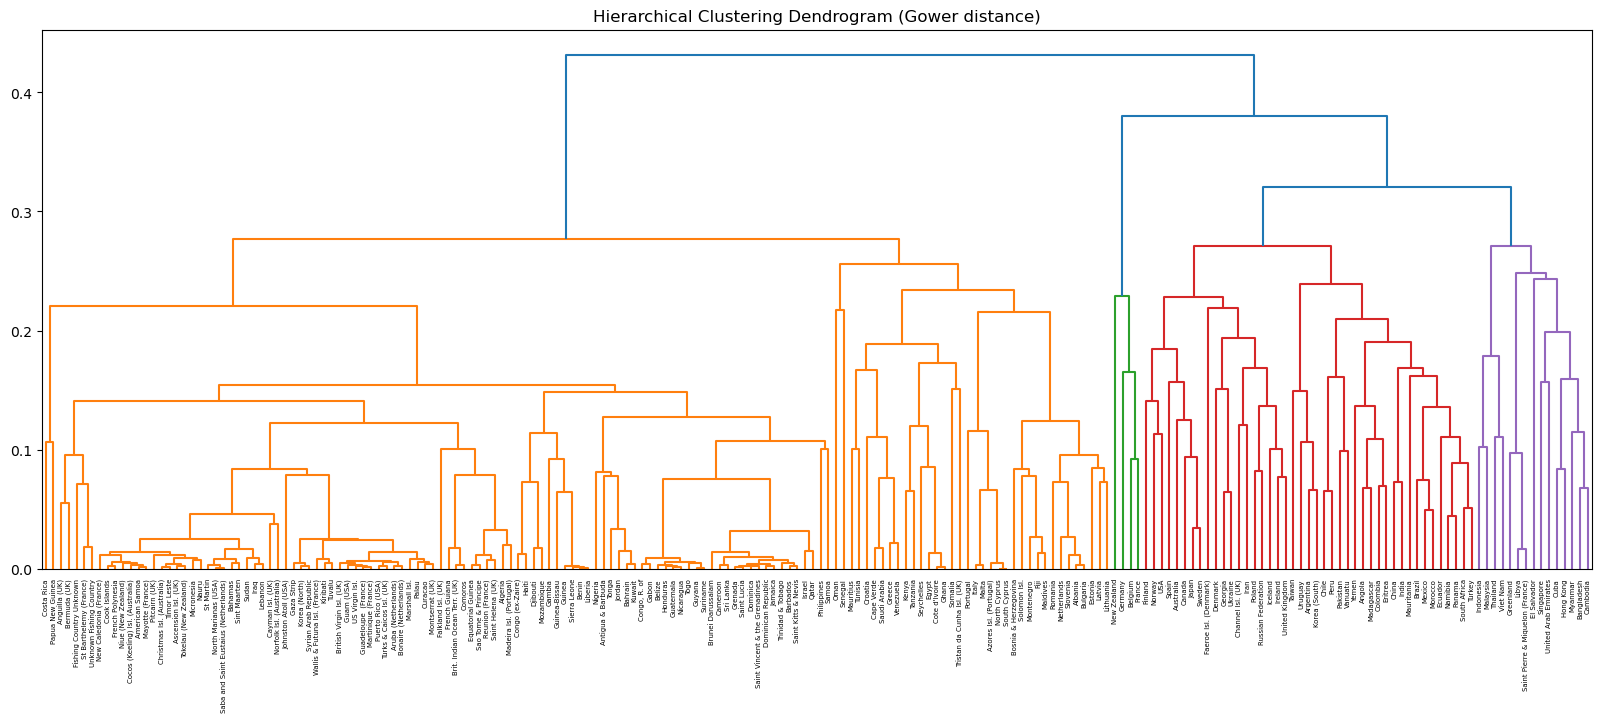

In [48]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
# 2. Convert the square 2D matrix into a 1D condensed distance matrix
condensed_matrix = squareform(distance_matrix)

# 3. Perform the hierarchical clustering
Z = linkage(condensed_matrix, method='average')

# 4. Plot the Dendrogram to visualize the splits
plt.figure(figsize=(20, 7))
plt.title("Hierarchical Clustering Dendrogram (Gower distance)")
dendrogram(Z, labels= final.index.tolist())
plt.show()

# 5. Extract the labels based on a distance threshold or a max number of clusters
# Here we cut the tree to get exactly 4 clusters
# scipy_labels = fcluster(Z, t=4, criterion='maxclust')

In [49]:
# Clustering algorithm
from sklearn.cluster import AgglomerativeClustering

## NMF profile with cashion groupings

The results of Gower distance calculation does not seem to work that well. It is may be due to the fact that categorical features in gower matrix naturally have a heavier weight than the numerical features, it has overwhelmingly skewed the groupings.

Is the results *really* not good?
- There is clearly one big group, but that could makes sense because most countries in there are ones without FMFO and we have no information on. so they should be grouped together.
- However, within the groups with FMFO, the grouping is not as clear and it is hard to make a judgement call on if it is group countries correctly.

Other possible ways to deal with this:
1) Do clustering within groups
- Try to tease out grouping from within the groupings that cashion has identified? Though technically because this is agglomerative clustering, we can just easily find the groupings within these groups by adjusting the distance threshold for within group vs outside of group.
2) Create NMF profiles
- Just as we used NMF to profile the FMFO factory composition of the countries. We can use NMF to create profiles based on observations by Cashion. Though in that case, maybe we can add species information to it also, because right now it is only based on if they have a dedicated FMFO fisheries/ using bait/ or using byproducts. 

- Color code the original cluster grouping and see how they compare to the gower distance based grouping?

In [50]:
final.shape

(200, 16)

In [51]:
final[final.index == 'Japan']

,GDP_per_capita,lat,Type 1,Type 2,Type 3,Type 4,Type 5,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type,scaled_factory_count
sau_name,,,,,,,,,,,,,,,,
Japan,0.349021,0.682233,0.0,0.0,0.0,0.0,0.0,Developed,dedicated_industry,y,y,y,y,n,A,0.227535


In [52]:
cashion_data.head()

,fishing_entity_id,name,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type
0,200,Alaska (USA),Others,Unknown,n,n,n,n,n,Unknown
1,1,Albania,Developed,only_bait,n,y,n,n,n,B
2,2,Algeria,Others,only_bait,n,n,n,y,n,C
3,3,American Samoa,Others,only_dhc,n,n,n,n,n,C
4,4,Angola,Least Developed,dedicated_industry,y,y,y,y,n,A


In [53]:
cashion_data[boolean_cols] = cashion_data[boolean_cols].replace({'n': 0, 'y': 1})

In [54]:
cashion_data

,fishing_entity_id,name,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type
0,200,Alaska (USA),Others,Unknown,0,0,0,0,0,Unknown
1,1,Albania,Developed,only_bait,0,1,0,0,0,B
2,2,Algeria,Others,only_bait,0,0,0,1,0,C
3,3,American Samoa,Others,only_dhc,0,0,0,0,0,C
4,4,Angola,Least Developed,dedicated_industry,1,1,1,1,0,A
...,...,...,...,...,...,...,...,...,...,...
212,190,Venezuela,Developing,dedicated_industry,0,1,1,1,0,B
213,161,Viet Nam,Developing,dedicated_industry,0,0,1,1,1,A
214,191,Wallis & Futuna Isl. (France),Others,only_bait,0,0,0,0,0,C
215,166,Western Sahara (Morocco),Others,Unknown,0,0,0,0,0,Unknown


In [55]:
cashion_data['wto_status'].unique()

<StringArray>
['Others', 'Developed', 'Least Developed', 'Developing']
Length: 4, dtype: str

In [56]:
# cashion_data['wto_status'] = cashion_data['wto_status'].replace({'Least Developed': 1, 'Developing': 2, 'Developed': 3, 'Others': 0})

# cashion_data['cashion_end_use_grouping'] = cashion_data['cashion_end_use_grouping'].replace({'only_dhc': 1, 'only_bait': 2, 'dedicated_industry': 3, 'Unknown': 0})

In [57]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

In [58]:
categorical_cols = ['wto_status', 'cashion_end_use_grouping', 'cashion_type']

ohe_df = encoder.fit_transform(cashion_data[categorical_cols])

In [59]:
one_hot_df = pd.DataFrame(ohe_df, 
                          columns=encoder.get_feature_names_out(categorical_cols))

In [60]:
one_hot_df

,wto_status_Developed,wto_status_Developing,wto_status_Least Developed,wto_status_Others,cashion_end_use_grouping_Unknown,cashion_end_use_grouping_dedicated_industry,cashion_end_use_grouping_only_bait,cashion_end_use_grouping_only_dhc,cashion_type_A,cashion_type_B,cashion_type_C,cashion_type_Unknown
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
212,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
213,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
214,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
215,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [61]:
ohe_cashion = cashion_data.drop(columns=categorical_cols+['fishing_entity_id']).join(one_hot_df).set_index('name')

In [62]:
ohe_cashion

,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,wto_status_Developed,wto_status_Developing,wto_status_Least Developed,wto_status_Others,cashion_end_use_grouping_Unknown,cashion_end_use_grouping_dedicated_industry,cashion_end_use_grouping_only_bait,cashion_end_use_grouping_only_dhc,cashion_type_A,cashion_type_B,cashion_type_C,cashion_type_Unknown
name,,,,,,,,,,,,,,,,,
Alaska (USA),0,0,0,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Albania,0,1,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
Algeria,0,0,0,1,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
American Samoa,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
Angola,1,1,1,1,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,0,1,1,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
Viet Nam,0,0,1,1,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
Wallis & Futuna Isl. (France),0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Nimfa optimization for cashion profiles

In [68]:
cashion_np = ohe_cashion.to_numpy()

In [70]:
import nimfa

In [71]:
nmf = nimfa.Nmf(cashion_np, max_iter=200, seed= 'random')

In [72]:
np.mat = np.asmatrix

In [73]:
rank_estimate = nmf.estimate_rank(rank_range=range(2, 15), 
                                  n_run=30, 
                                  what=['cophenetic', 'rss'])

In [74]:
# 3. Extract the results
ranks = list(rank_estimate.keys())
coph_scores = [rank_estimate[r]['cophenetic'] for r in ranks]
rss_scores = [rank_estimate[r]['rss'] for r in ranks]

In [75]:
import matplotlib.pyplot as plt

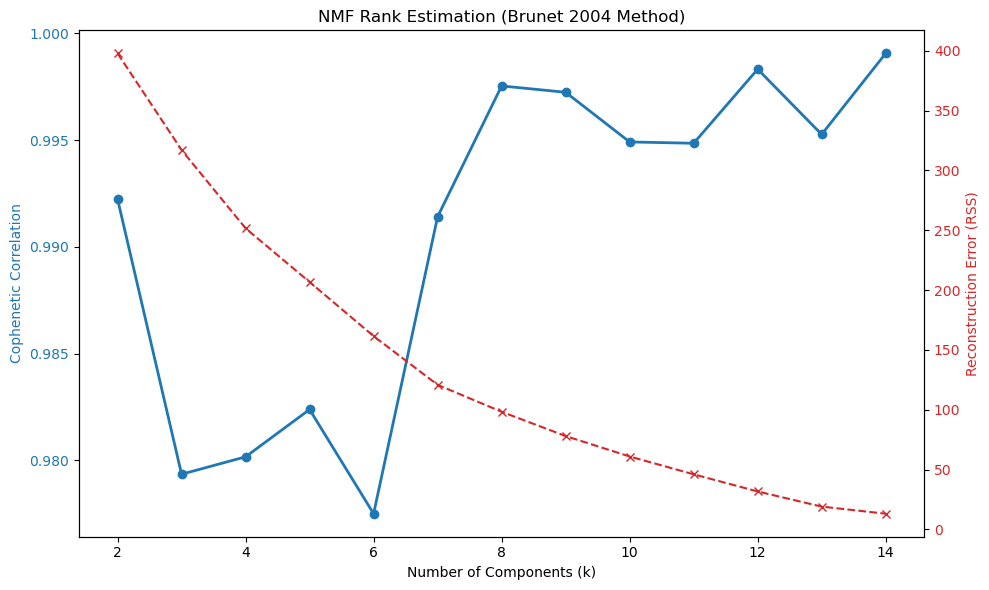

In [76]:
# 4. Plot the results to find the "drop-off"
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Cophenetic Correlation (Look for the drop-off)
color = 'tab:blue'
ax1.set_xlabel('Number of Components (k)')
ax1.set_ylabel('Cophenetic Correlation', color=color)
ax1.plot(ranks, coph_scores, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Plot Reconstruction Error (Look for the elbow)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Reconstruction Error (RSS)', color=color)  
ax2.plot(ranks, rss_scores, marker='x', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("NMF Rank Estimation (Brunet 2004 Method)")
fig.tight_layout()  
plt.show()

In [63]:
from dimension_reduction import dimension_reduction

In [77]:
cashion_W, cashion_H = dimension_reduction(ohe_cashion, n_components=8)

In [78]:
plot_top_categories(cashion_H, 10, False)

alt.FacetChart(...)

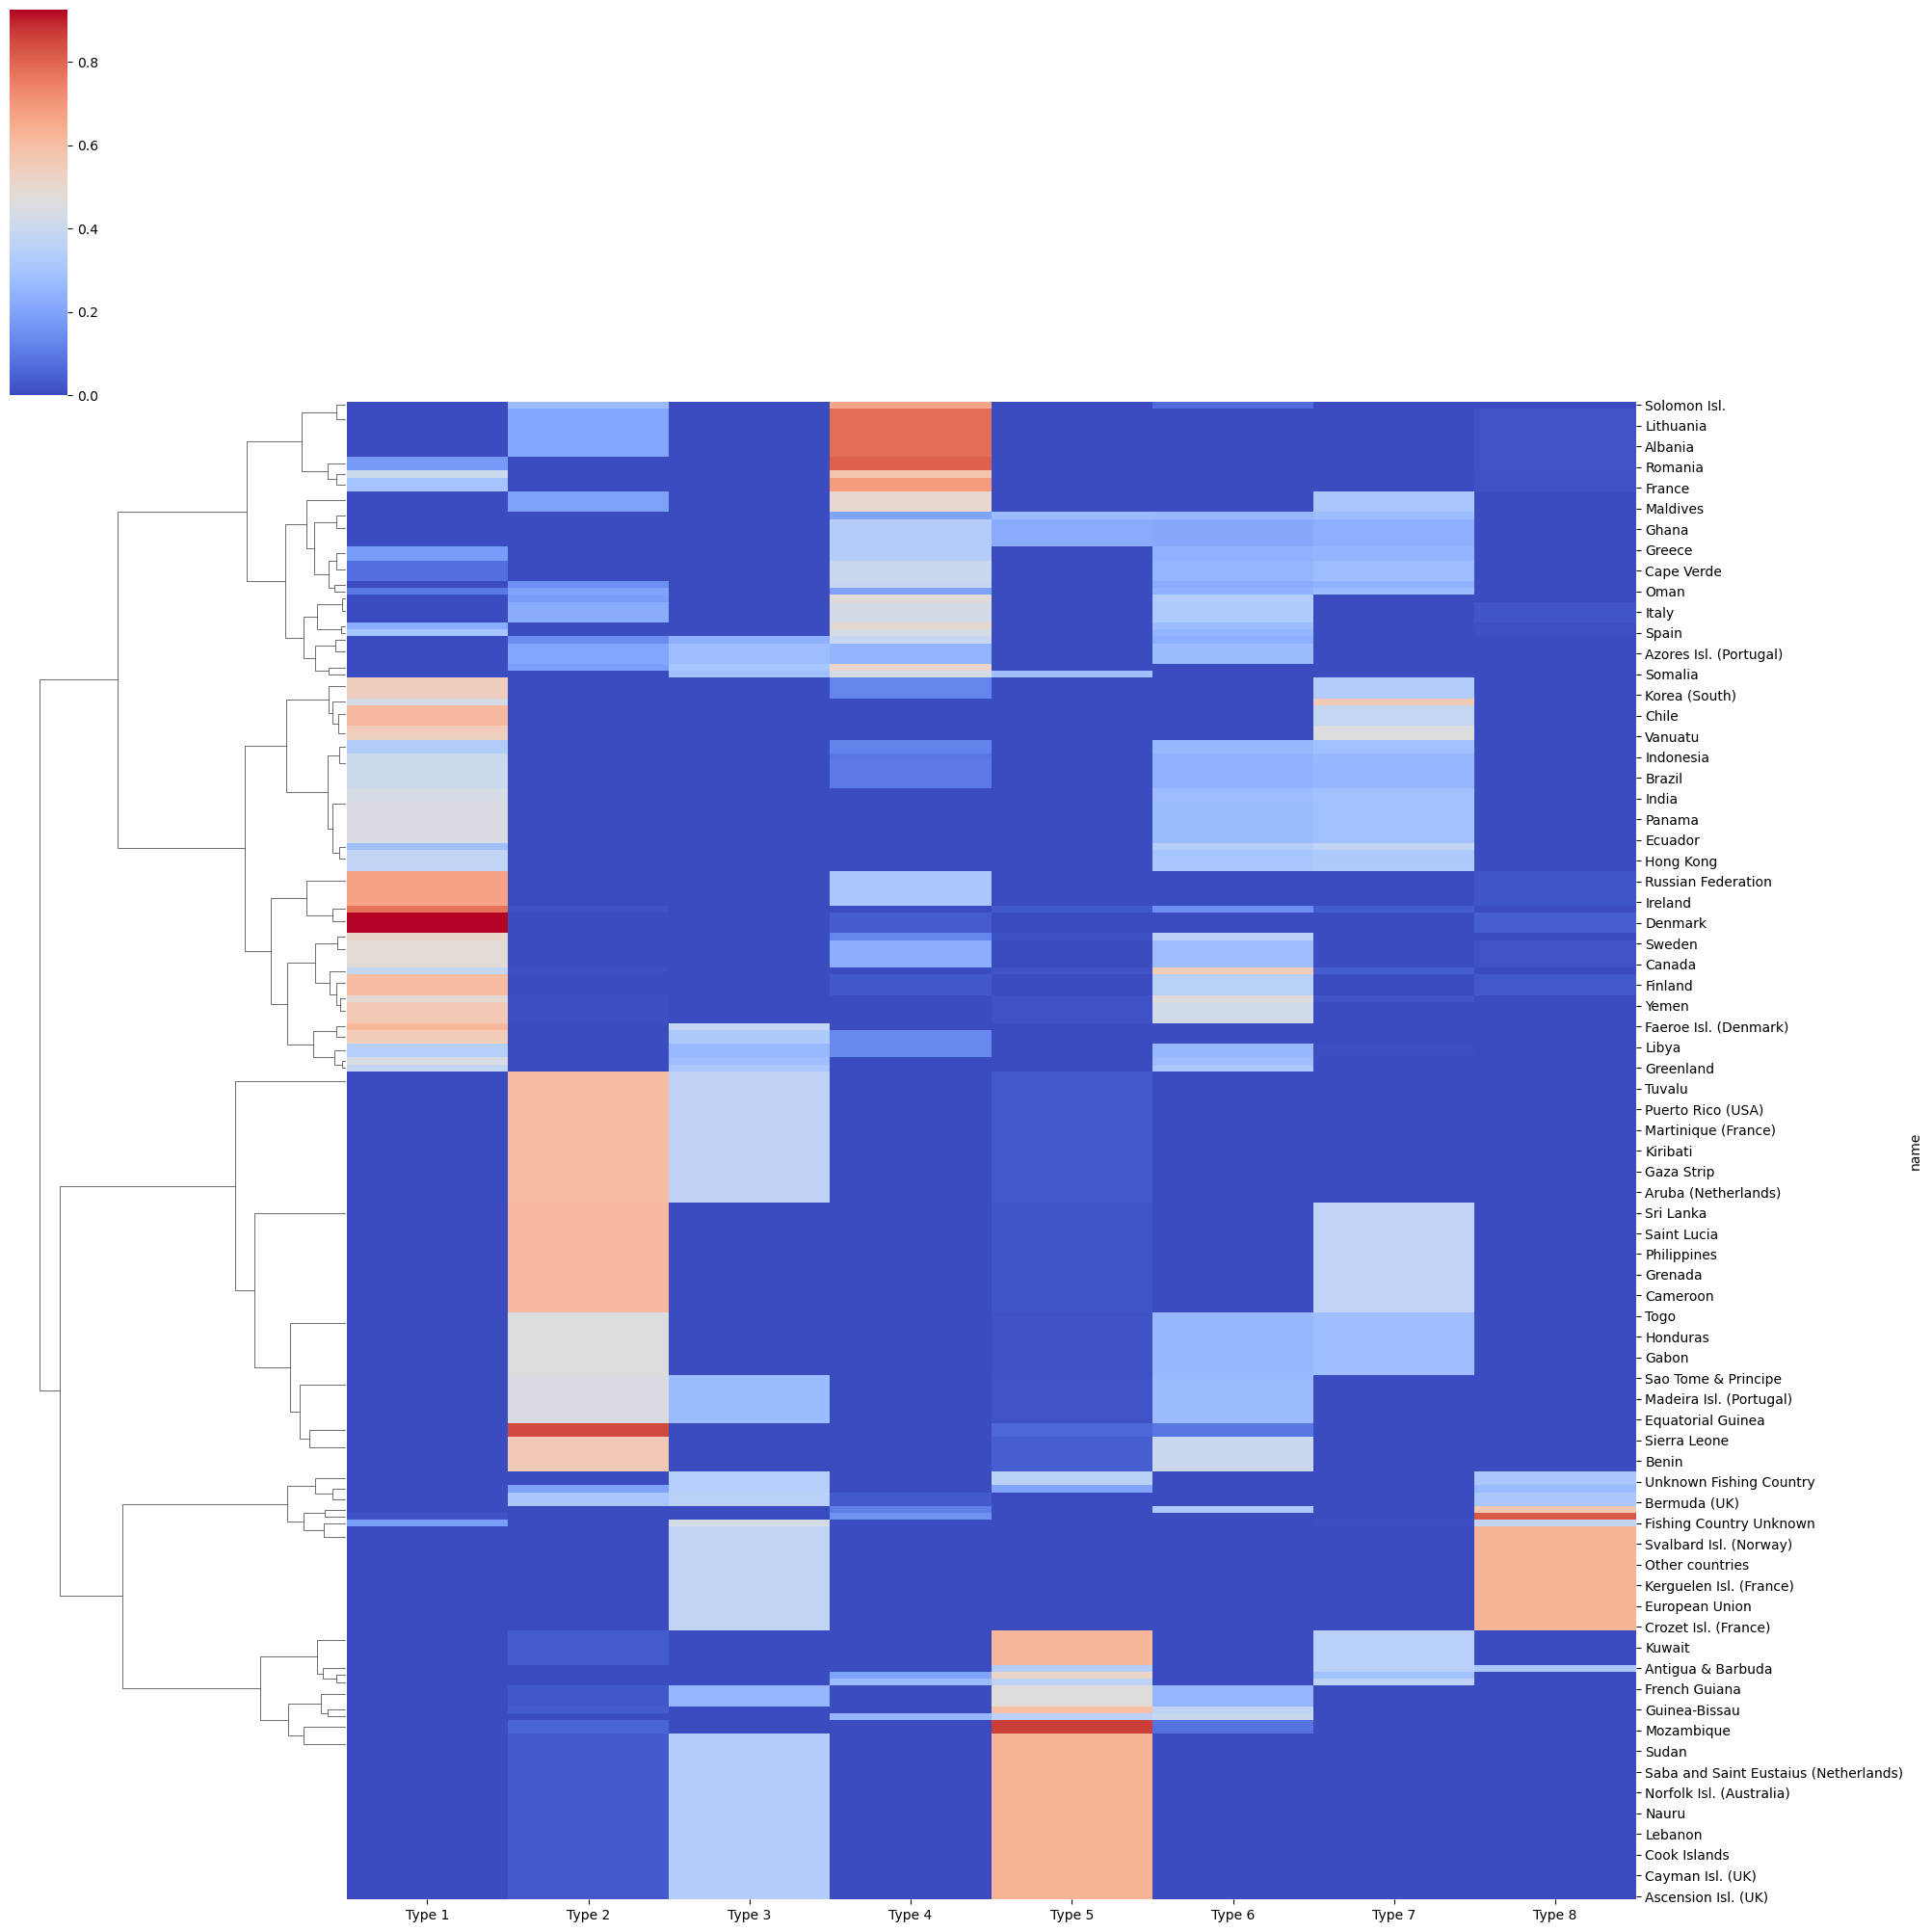

In [ ]:
plot_heatmap(cashion_W, save_fig=False)

In [86]:
final[['GDP_per_capita', 'lat', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'scaled_factory_count']]

,GDP_per_capita,lat,Type 1,Type 2,Type 3,Type 4,Type 5,scaled_factory_count
sau_name,,,,,,,,
Albania,0.052414,0.749789,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Algeria,0.038588,0.718843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
American Samoa,0.111281,0.308669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Angola,0.021535,0.330105,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Anguilla (UK),0.221200,0.581420,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
Vanuatu,0.027699,0.266471,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Venezuela,0.021789,0.521691,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Viet Nam,0.029715,0.529300,0.064751,0.476772,0.079714,0.015345,0.363417,0.574235


In [92]:
cashion_W.rename(columns={'Type 1': 'cashion_type_1', 'Type 2': 'cashion_type_2', 'Type 3': 'cashion_type_3', 'Type 4': 'cashion_type_4', 'Type 5': 'cashion_type_5', 'Type 6': 'cashion_type_6', 'Type 7': 'cashion_type_7', 'Type 8': 'cashion_type_8'}, inplace=True)

In [93]:
cashion_W

,cashion_type_1,cashion_type_2,cashion_type_3,cashion_type_4,cashion_type_5,cashion_type_6,cashion_type_7,cashion_type_8
name,,,,,,,,
Alaska (USA),0.000000,0.000000,0.372808,0.000000,0.000000,0.000000,0.000000,0.627192
Albania,0.000000,0.203690,0.000000,0.781332,0.000000,0.000000,0.000000,0.014978
Algeria,0.000000,0.446571,0.270482,0.000000,0.017557,0.265391,0.000000,0.000000
American Samoa,0.000000,0.031745,0.339379,0.000000,0.628876,0.000000,0.000000,0.000000
Angola,0.509052,0.000000,0.000000,0.125018,0.008851,0.357080,0.000000,0.000000
...,...,...,...,...,...,...,...,...
Venezuela,0.177969,0.000000,0.000000,0.339984,0.000000,0.235889,0.246158,0.000000
Viet Nam,0.371869,0.000000,0.000186,0.000000,0.000000,0.304491,0.323454,0.000000
Wallis & Futuna Isl. (France),0.000000,0.606680,0.366263,0.000000,0.027057,0.000000,0.000000,0.000000


In [95]:
combo = final[['GDP_per_capita', 'lat', 'Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'scaled_factory_count']].join(cashion_W)

In [103]:
from hierarchical_clustering import plot_dendrogram, plot_heatmap

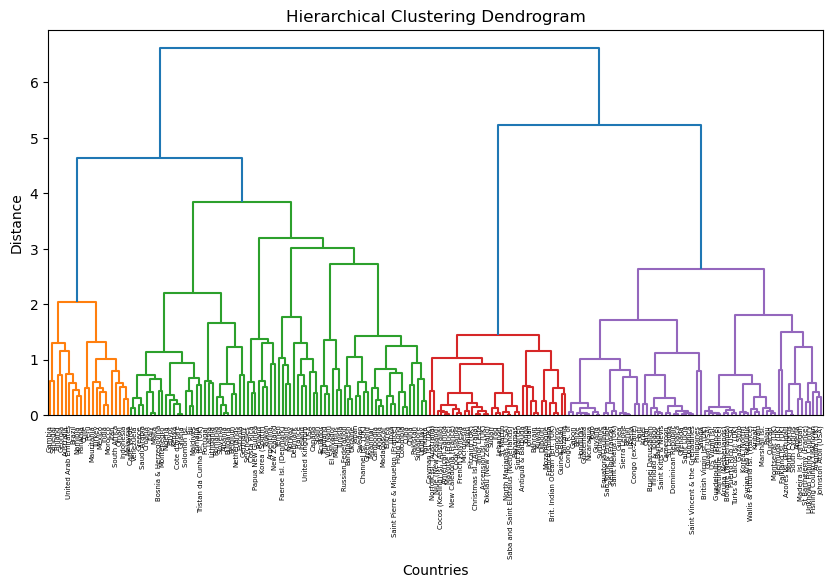

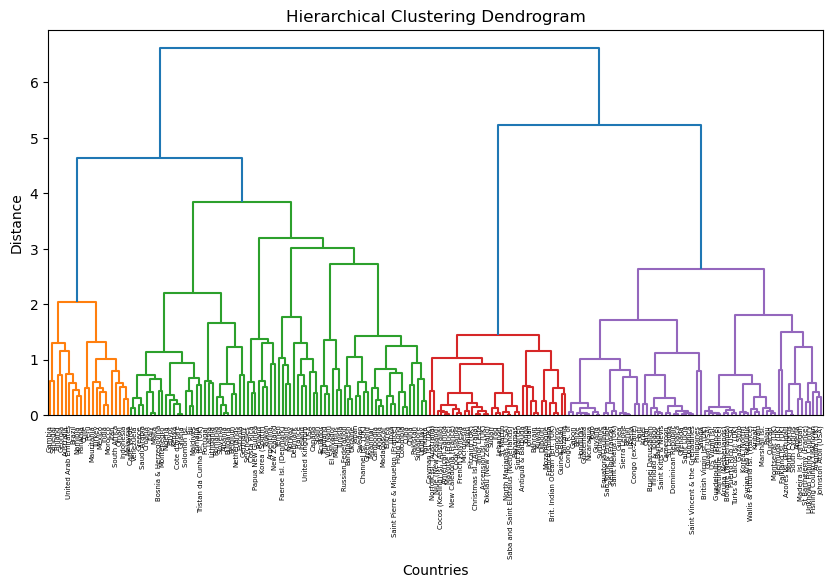

In [104]:
plot_dendrogram(combo, save_fig=False)

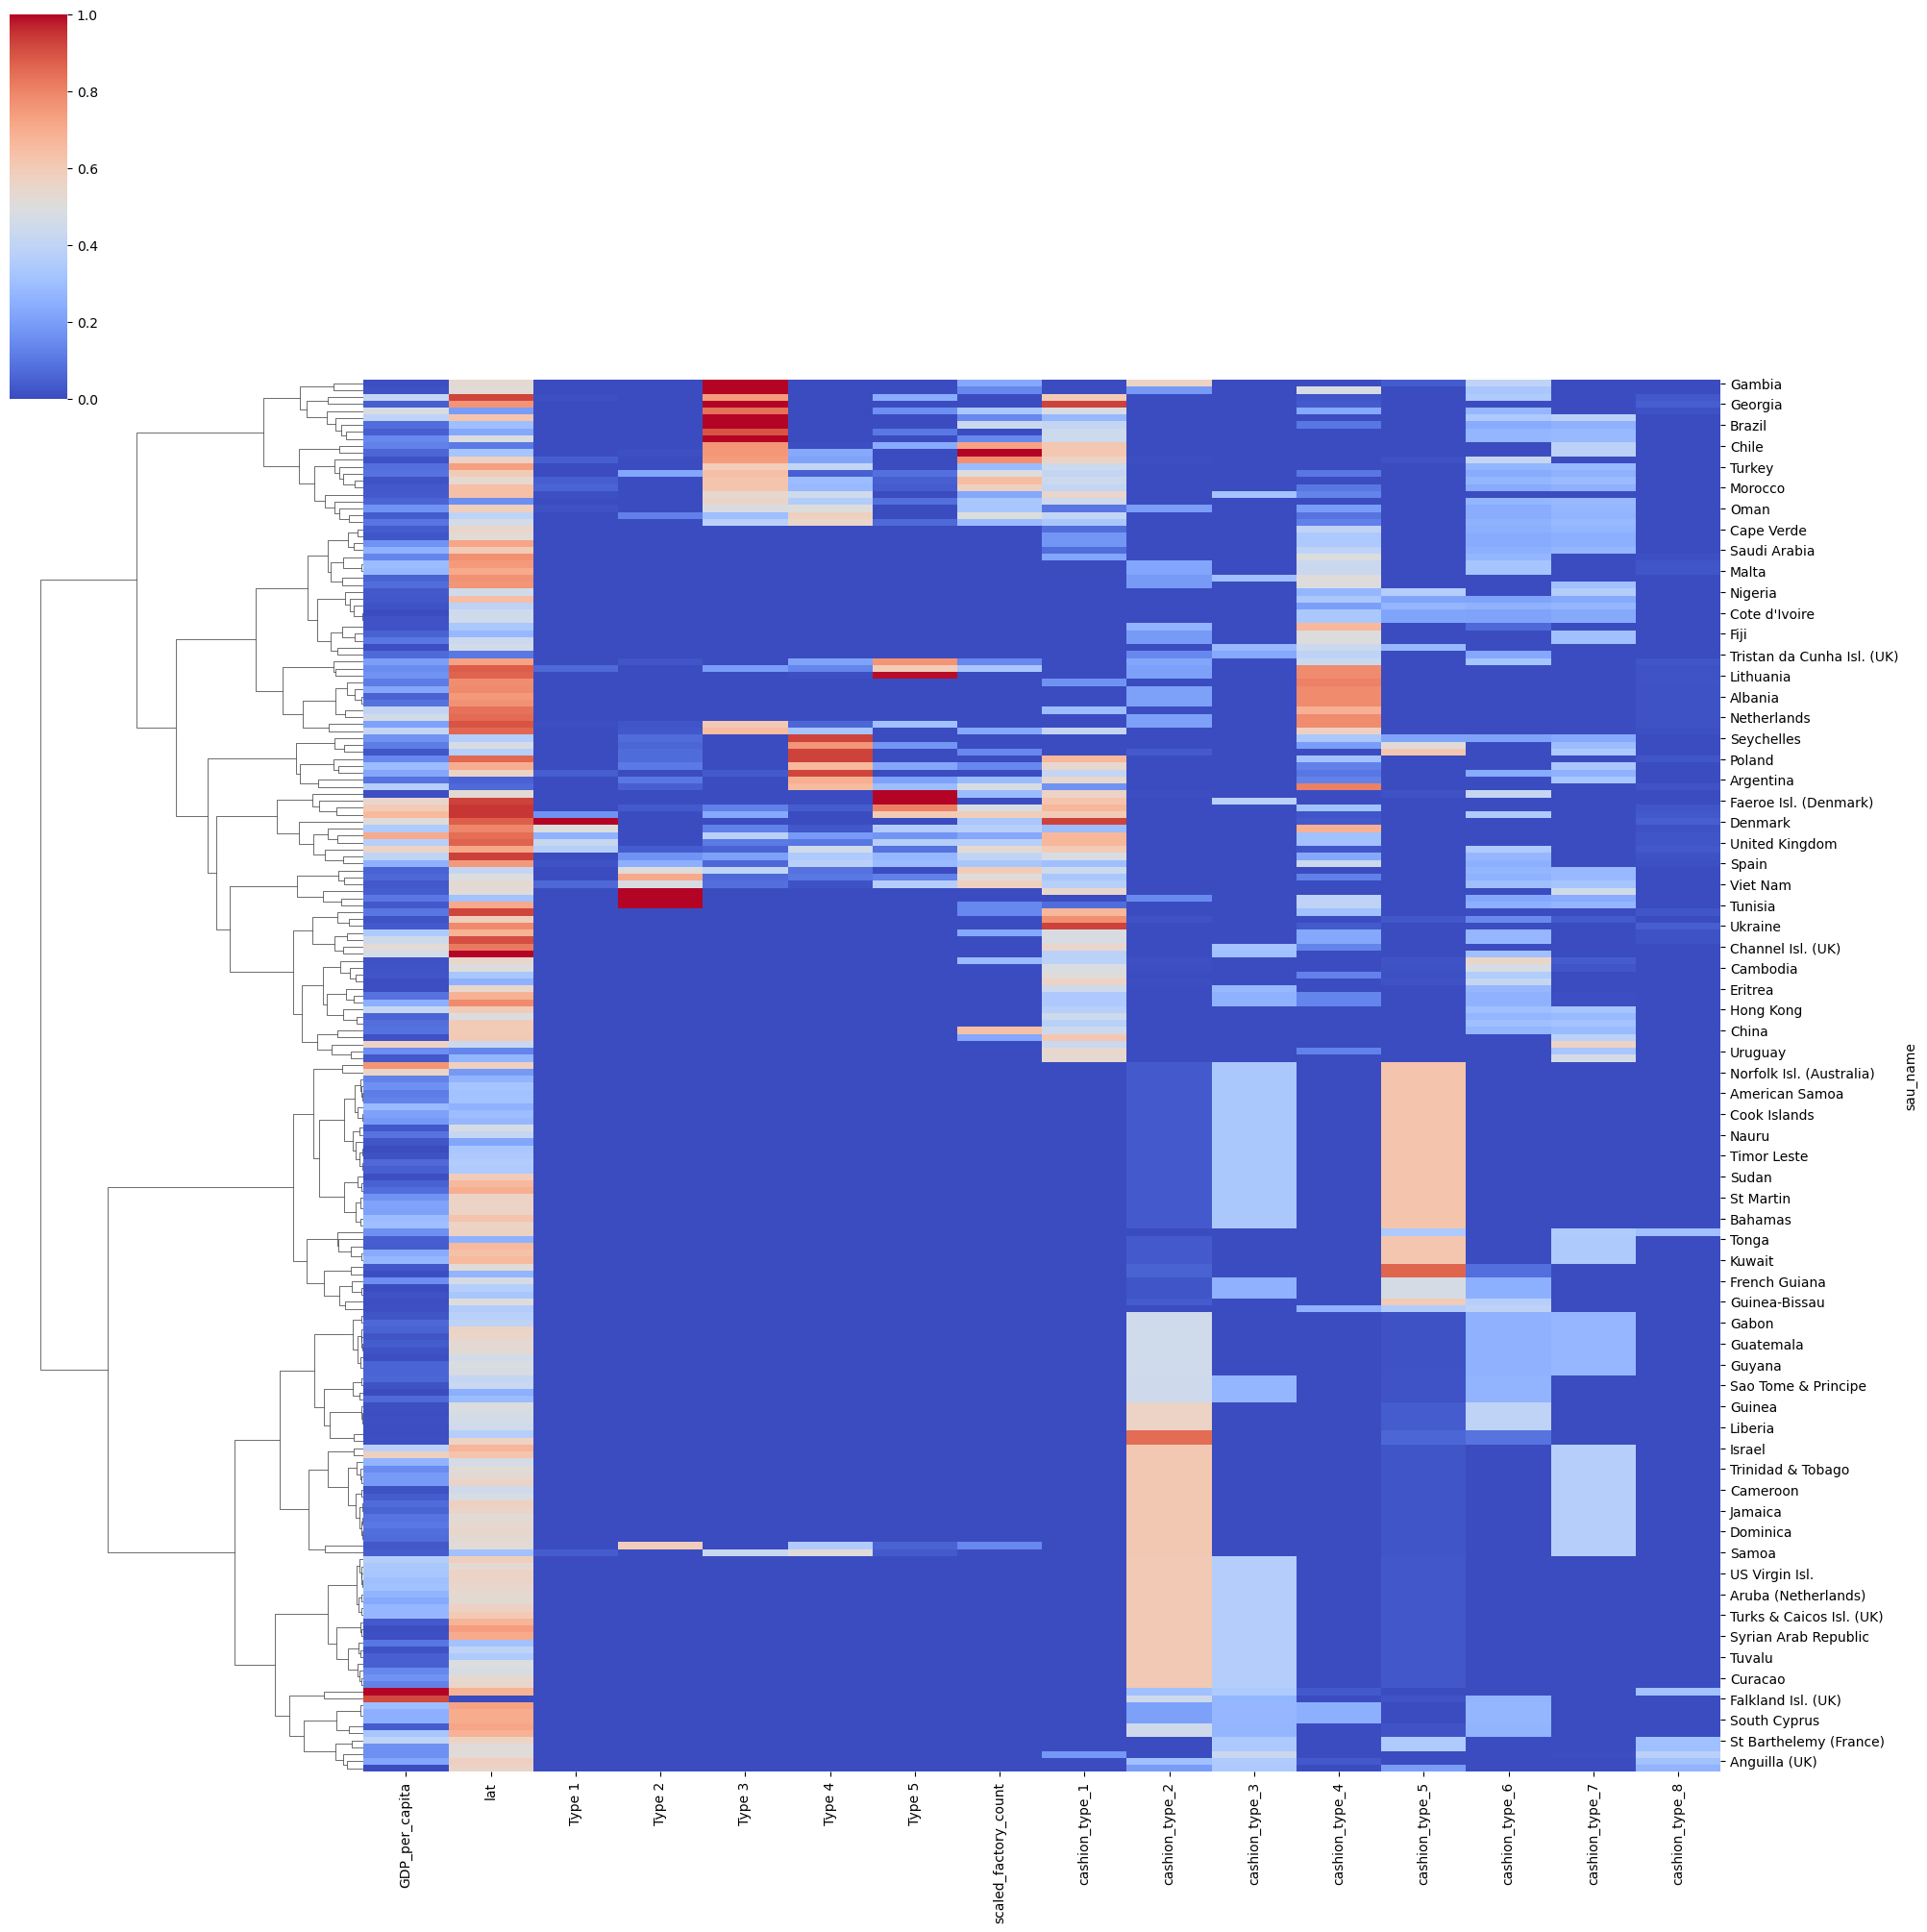

In [100]:
plot_heatmap(combo, save_fig=False)

Text(0, 0.5, 'Distance')

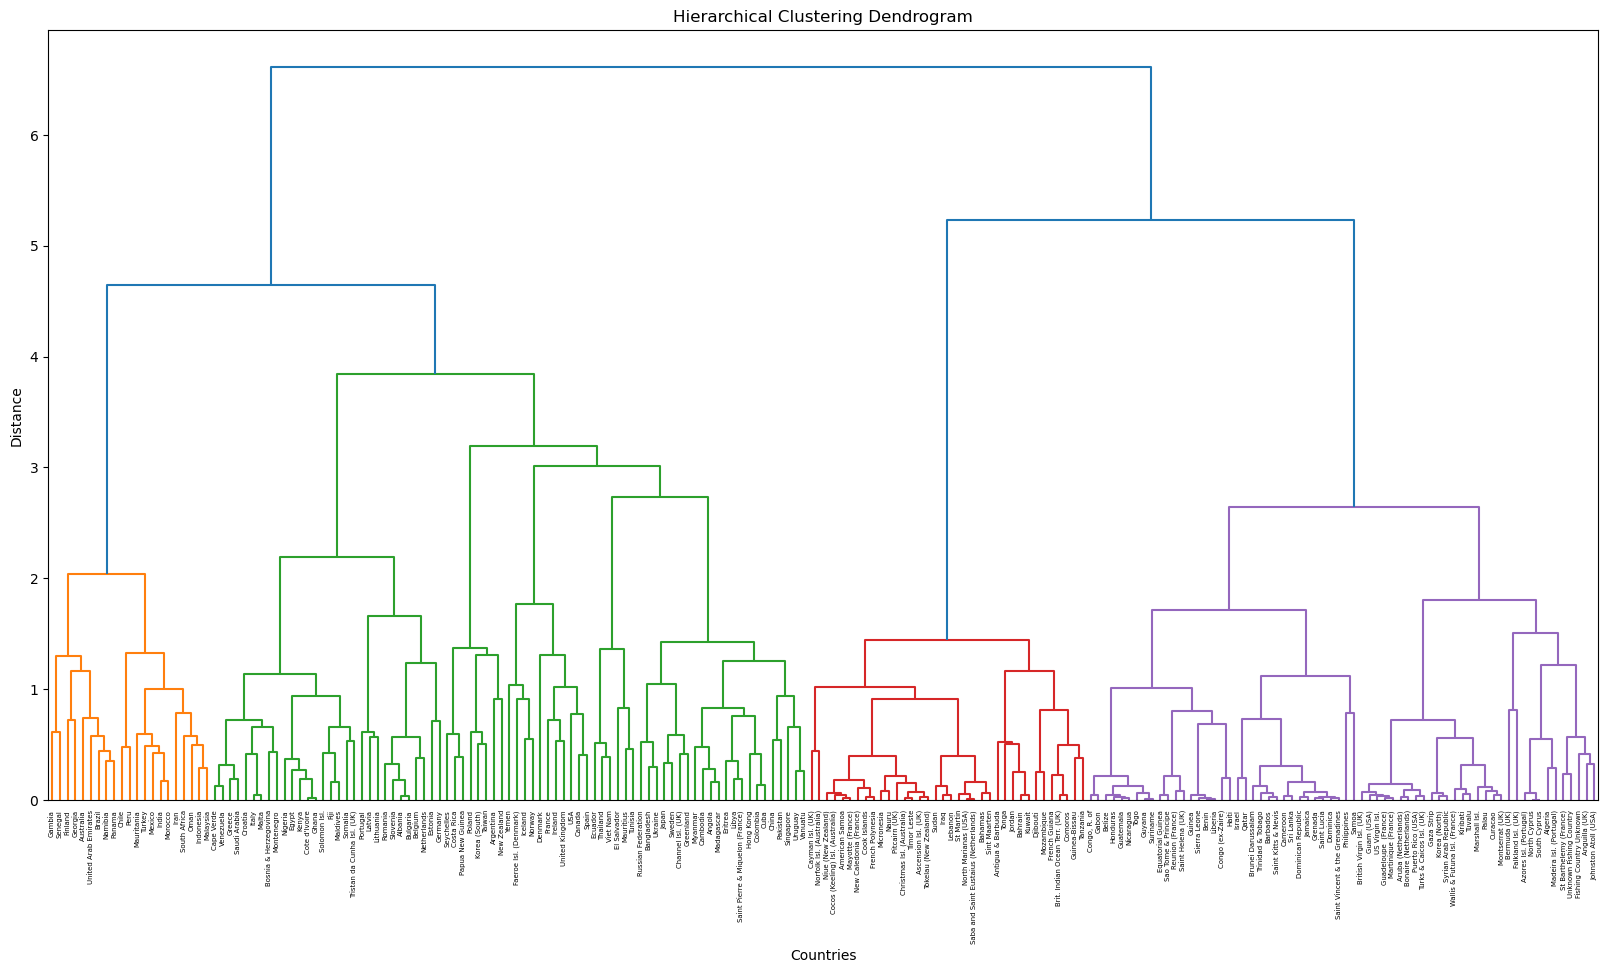

In [105]:
linkage_matrix = ward(combo)

# Plot the dendrogram
fig = plt.figure(figsize=(20, 10))
dendrogram(linkage_matrix, labels=combo.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Distance')

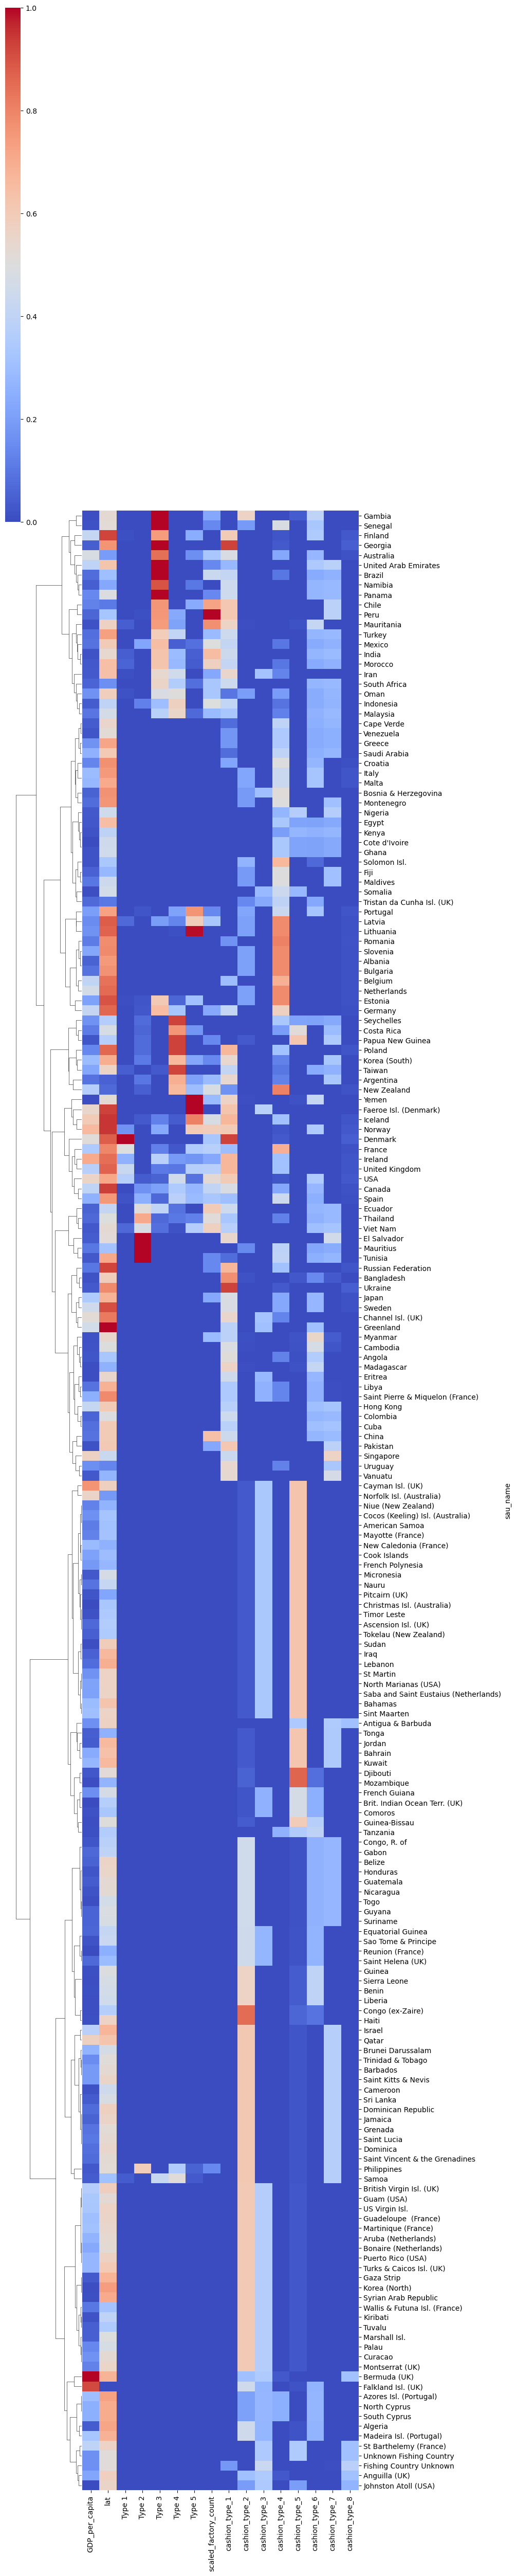

In [111]:
heatmap = sns.clustermap(combo, method='ward', cmap='coolwarm', figsize=(
10 , 50), cbar_pos=(0, 0.8, .03, .2), row_cluster=True, col_cluster=False)

In [112]:
combo

,GDP_per_capita,lat,Type 1,Type 2,Type 3,Type 4,Type 5,scaled_factory_count,cashion_type_1,cashion_type_2,cashion_type_3,cashion_type_4,cashion_type_5,cashion_type_6,cashion_type_7,cashion_type_8
sau_name,,,,,,,,,,,,,,,,
Albania,0.052414,0.749789,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.203690,0.000000,0.781332,0.000000,0.000000,0.000000,0.014978
Algeria,0.038588,0.718843,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.446571,0.270482,0.000000,0.017557,0.265391,0.000000,0.000000
American Samoa,0.111281,0.308669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031745,0.339379,0.000000,0.628876,0.000000,0.000000,0.000000
Angola,0.021535,0.330105,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.509052,0.000000,0.000000,0.125018,0.008851,0.357080,0.000000,0.000000
Anguilla (UK),0.221200,0.581420,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.308155,0.350694,0.028957,0.000000,0.000000,0.000000,0.312194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,0.027699,0.266471,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.533905,0.000002,0.000307,0.000000,0.000000,0.000000,0.465786,0.000000
Venezuela,0.021789,0.521691,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.177969,0.000000,0.000000,0.339984,0.000000,0.235889,0.246158,0.000000
Viet Nam,0.029715,0.529300,0.064751,0.476772,0.079714,0.015345,0.363417,0.574235,0.371869,0.000000,0.000186,0.000000,0.000000,0.304491,0.323454,0.000000


In [114]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(combo, method='ward', metric='euclidean')

max_d = 1.5  # This is a distance threshold you can adjust

cluster_labels = fcluster(Z, t=max_d, criterion='distance')

results = pd.DataFrame({'Country': combo.index, 'Cluster': cluster_labels})

In [117]:
results.to_csv('../results/country_clusters.csv', index=False)